# Signal Engine — v2.4
**General-purpose signal IC analysis and alpha combination framework**

Point at any asset universe and signal library via the Configuration cell.
The combination engine, regime conditioning, and mega-alpha run without modification.

**v2 → v2.1:** Weight gate, regime-aware weights, sign override map
**v2.1 → v2.2:** ε rank-normalization, full parameterization
**v2.2 → v2.3:** Cell 2.5 correlation diagnostic, STUDY_LOG, semis override findings
**v2.3 → v2.4:**
- Tier 3: Short Interest signals (SI_Ratio, SI_DaysToCover, SI_Change_21d)
  Pulled from yfinance info + FINRA bi-monthly short interest data
- Tier 4: Earnings Estimate Revision signals (EPS_Revision_Dir, EPS_Surprise)
  Pulled from Financial Modeling Prep free API
- Tier 5: Credit Market signals (CreditSpread, CreditSpread_Change, YieldCurve_Slope)
  Pulled from yfinance (HYG, LQD, ^IRX, ^TNX) — no new vendor needed
- New config constants: FMP_API_KEY, SI_GATE, REVISION_LOOKBACK
- Cell 3.2: Fundamental & Credit data pull (separate from price data pull)
- Cell 3.3: Tier 3/4/5 signal construction functions
- Signal dict extended with 8 new signals
- KEEP_SIGNALS updated to include new signals after first IC run

---

## 0. Dependencies & Environment

In [45]:
!pip install yfinance pandas numpy scipy matplotlib seaborn requests -q

from google.colab import drive
import os
drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/factor-strength-study'
os.makedirs(FOLDER, exist_ok=True)

import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from scipy.stats import rankdata
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

print('Environment ready.')
print(f'Output folder: {FOLDER}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready.
Output folder: /content/drive/MyDrive/factor-strength-study


## 1. Configuration

In [46]:
# =============================================================================
# CONFIGURATION — edit this cell only when switching asset universes
# =============================================================================

# --- Study log ---
# Every universe you have run. Switch by changing STUDY_NAME below.
STUDY_LOG = {

    # ── Completed studies ────────────────────────────────────────────────────
    'photonics-factor-strength': ['AAOI', 'COHR', 'AEHR', 'LITE', 'IPGP'],
    'semis-factor-strength':     ['NVDA', 'AMD',  'AVGO', 'MRVL', 'QCOM'],
    'ai-stack-study': [            # 23-name broad scan — run for diagnostic only
        'LITE', 'AMD',  'COHR', 'MRVL', 'GOOG', 'VRT',  'GLD',
        'EQIX', 'AVGO', 'SNDR', 'ANET', 'VST',  'SNDK', 'CSCO',
        'ETN',  'NOW',  'ZETA', 'NVDA', 'MSFT', 'CRDO', 'DLR',
        'AMZN', 'ALAB',
    ],
    'ai-optical-connectivity': ['LITE', 'COHR', 'CRDO', 'ALAB', 'ANET',
                                 'MRVL', 'AVGO'],
    'ai-compute-cloud':        ['NVDA', 'AMD',  'GOOG', 'MSFT', 'AMZN'],
    'ai-infrastructure':       ['VRT',  'ETN',  'VST',  'EQIX', 'DLR', 'CSCO'],
    'flagged-for-review':      ['SNDR', 'GLD',  'NOW',  'ZETA', 'SNDK'],

    # ── Thesis-driven universes (run in recommended order) ───────────────────

    # 1. Power Grid & Grid Modernization
    # Signal focus: rate-sensitive, capex-driven, regulatory gated
    # Key: PWR/MYR = construction; ETN/HUBB/GE = equipment; CEG/VST = generation
    'power-grid': [
        'ETN',  # Eaton — transformers, switchgear, power management
        'EMR',  # Emerson Electric — automation, grid equipment
        'HUBB', # Hubbell — electrical products, utility infrastructure
        'GEV',  # GE Vernova — grid equipment, wind, gas turbines
        'PWR',  # Quanta Services — grid construction, transmission
        'MYR',  # MYR Group — electrical construction for utilities
        'AES',  # AES Corp — renewables, battery storage, DC power PPAs
        'AME',  # AMETEK — electronic instruments, electromechanical devices
    ],

    # 2. AI Compute & Data Centers — full universe
    # Signal focus: hyperscaler capex correlated, momentum-driven
    # Note: run correlation diagnostic first — NVDA/AMD will be tight
    # Sub-universe A: compute silicon
    'ai-compute-silicon': [
        'NVDA', # Nvidia — GPU, HGX, inference dominance
        'AMD',  # AMD — MI300X, alternative GPU/CPU
        'AVGO', # Broadcom — custom ASICs (Google TPU, Meta MTIA)
        'MRVL', # Marvell — custom silicon, DPUs, optical DSPs
    ],
    # Sub-universe B: data center infrastructure
    'ai-dc-infrastructure': [
        'VRT',  # Vertiv — power, cooling, DC infrastructure
        'SMCI', # Super Micro — GPU servers, liquid cooling (high SI)
        'AAON', # AAON — precision cooling for data centers
        'EQIX', # Equinix — colocation, interconnection
        'DLR',  # Digital Realty — wholesale DC, hyperscaler leases
    ],

    # 3. Defense Technology & Rearmament
    # Signal focus: contract-driven, backlog visibility, macro-independent
    # Note: PLTR behaves like tech — track separately from primes
    'defense-tech': [
        'LMT',  # Lockheed Martin — F-35, hypersonics, missile defense
        'RTX',  # RTX/Raytheon — Patriot, LTAMDS, missile systems
        'NOC',  # Northrop Grumman — B-21, space, autonomous systems
        'LHX',  # L3Harris — comms, ISR, electronic warfare
        'KTOS', # Kratos Defense — unmanned systems, drone targets
        'AVAV', # AeroVironment — small UAS, Switchblade loitering munition
        'PLTR', # Palantir — AI for defense, AIP, Maven Smart System
        'BAESY',# BAE Systems ADR — UK prime, ammunition, armored vehicles
    ],

    # 4A. Nuclear — Operators (near-term, PPA-driven)
    # Signal focus: policy-gated, PPA announcement driven
    'nuclear-operators': [
        'CEG',  # Constellation Energy — largest US nuclear, Microsoft deal
        'VST',  # Vistra — Comanche Peak, nuclear + gas merchant
        'ETR',  # Entergy — nuclear in regulated utility structure
        'BWXT', # BWX Technologies — nuclear components, naval reactors
    ],

    # 4B. Nuclear — Uranium Supply Chain
    # Signal focus: uranium spot price correlated, mine development timelines
    'uranium-supply': [
        'CCJ',  # Cameco — largest western uranium miner
        'UEC',  # Uranium Energy Corp — US-based ISR uranium
        'NXE',  # NexGen Energy — Athabasca Basin, Rook I project
        'URA',  # Global X Uranium ETF — diversified uranium (ETF as signal)
    ],

    # 5. Semiconductor Supply Chain & Advanced Manufacturing
    # Signal focus: book-to-bill ratio, utilization, export control events
    # Note: run correlation diagnostic — AMAT/LRCX/KLAC will be tight
    'semi-supply-chain': [
        'AMAT', # Applied Materials — deposition, etch, inspection
        'LRCX', # Lam Research — etch and deposition leader
        'KLAC', # KLA Corp — process control, defect inspection
        'ASML', # ASML — EUV lithography monopoly (ADR)
        'AMKR', # Amkor Technology — OSAT, advanced packaging
        'ENTG', # Entegris — specialty materials, CMP, filtration
        'MKSI', # MKS Instruments — gas delivery, RF power for fabs
        'COHU', # Cohu — test handlers and contactors
    ],

    # 6. Autonomous & Robotic Systems
    # Signal focus: order flow, pilot-to-contract conversion, defense awards
    # Note: dropped TSLA (too noisy), FANUY (ADR liquidity)
    'autonomous-robotics': [
        'ROK',  # Rockwell Automation — factory automation, PLC, SCADA
        'BRKS', # Brooks Automation — semiconductor handling robots
        'KTOS', # Kratos Defense — unmanned systems (cross-listed w/ defense)
        'AVAV', # AeroVironment — tactical UAS (cross-listed w/ defense)
        'QCOM', # Qualcomm — Snapdragon Edge AI, automotive autonomy
        'ABB',  # ABB Ltd — industrial robots, automation (Swiss, NYSE listed)
    ],

    # 7. Sovereign AI — overlay thesis, hardest to trade directly
    # Best plays are private (G42, Digital Edge)
    # Use as a macro signal overlay on universes 1 and 2 rather than standalone
    # Included here for completeness; IC may be weak due to heterogeneity
    'sovereign-ai': [
        'EQIX', # Equinix — global colocation, sovereign AI JV partner
        'NVDA', # Nvidia — sovereign AI chip sales, export approval dependent
        'SMCI', # SMCI — server systems for sovereign DC buildouts
        'ASTS', # AST SpaceMobile — satellite broadband, emerging markets
        'VSAT', # Viasat — satellite connectivity, sovereign comms
    ],

    # ── Speculative / watch list (not engine-ready) ──────────────────────────
    # These names have insufficient liquidity or are pre-revenue.
    # Monitor for entry once market cap / float grows.
    'watch-speculative': [
        'OKLO', # Oklo — Aurora microreactor, Sam Altman backed (pre-revenue)
        'NNE',  # Nano Nuclear — mobile microreactors (pre-revenue)
        'RCAT', # Red Cat — military drone swarms (low float)
        'MVIS', # MicroVision — automotive lidar (speculative)
        'ACHR', # Archer Aviation — defense eVTOL (pre-revenue)
    ],
}

# --- Active study (change this line to switch universes) ---
STUDY_NAME = 'ai-infrastructure'
UNIVERSE   = STUDY_LOG[STUDY_NAME]

# --- Macro regime tickers ---
# Always include VIX and TNX. Add sector overlays as needed.
MACRO_TICKERS = ['^VIX', '^SOX', '^TNX', 'USO', '^GSPC', 'QQQ']

# --- Drive output folder ---
FOLDER = f'/content/drive/MyDrive/factor-strength-study/{STUDY_NAME}'

# --- Data range ---
START = '2022-01-01'
END   = None  # None = today

# --- Forward return horizons (trading days) ---
HORIZONS = [1, 3, 5, 10, 21]

# --- Signal construction windows ---
VOL_WINDOW  = 10
SMA_WINDOW  = 200
EMA_FAST    = 9
EMA_SLOW    = 21
BB_WINDOW   = 20
BB_STD      = 2.0

# --- Combination engine ---
D_LOOKBACK    = 21    # Step 8 rolling window for expected return
VIX_THRESHOLD = 20.0  # VIX above = risk-off regime
TNX_THRESHOLD = 4.5   # TNX above = high-rate regime (%)

# --- Universe correlation gate (Cell 2.5) ---
CORR_GATE   = 0.85   # pairs above this flagged redundant
CORR_WINDOW = 63     # trading days for recent correlation (~3 months)

# --- Culling thresholds ---
IC_MIN   = 0.03
CORR_MAX = 0.70

# --- Approved signals ---
KEEP_SIGNALS = [
    'SMA200_Distance',
    'Momentum_21d',
    'EMA_Cross_9_21',
    'Bollinger_Pct_B',
    'Momentum_10d',
    'Volume_Surge',
    'VIX_Regime',
]

# --- Ticker-signal sign overrides ---
# Clear when switching to a new universe.
# Run engine once, read regime_conditional_ic.csv, then populate.
# Overrides only fire for tickers present in UNIVERSE.
TICKER_SIGNAL_OVERRIDES = {
    # Photonics study
    # LITE SMA200: momentum continuation active (IC=+0.263), reverts risk_off (IC=-0.495)
    ('SMA200_Distance', 'LITE', 'risk_off'): -1,

    # Semis study (v2.3)
    # SMA200 uniformly bearish for large-cap semis. Mean IC=-0.177 across universe.
    ('SMA200_Distance', 'NVDA', 'active'): -1,
    ('SMA200_Distance', 'AMD',  'active'): -1,
    ('SMA200_Distance', 'AVGO', 'active'): -1,
    ('SMA200_Distance', 'MRVL', 'active'): -1,
    ('SMA200_Distance', 'QCOM', 'active'): -1,
}

# --- Override evidence (reference only, not used in computation) ---
OVERRIDE_NOTES = {
    ('SMA200_Distance', 'LITE', 'risk_off'): {
        'IC_active': +0.263, 'IC_riskoff': -0.495,
        'source': 'photonics v2.1',
        'note': 'Structural uptrend = continuation active; reverts at TNX>=4.5%',
    },
    ('SMA200_Distance', 'NVDA', 'active'): {
        'IC_vix_low': +0.068, 'IC_vix_high': -0.274,
        'source': 'semis v2.3',
        'note': 'Post-peak mean reversion in sample',
    },
    ('SMA200_Distance', 'AVGO', 'active'): {
        'IC_vix_low': -0.267, 'IC_vix_high': -0.453,
        'source': 'semis v2.3',
        'note': 'Strongest reversion in semis, consistent both regimes',
    },
    ('SMA200_Distance', 'MRVL', 'active'): {
        'IC_vix_low': -0.346, 'IC_vix_high': -0.080,
        'source': 'semis v2.3',
        'note': 'Strong active regime; risk-off effect smaller sample',
    },
    ('SMA200_Distance', 'AMD',  'active'): {
        'IC_vix_low': -0.054, 'IC_vix_high': -0.329,
        'source': 'semis v2.3',
        'note': 'Directionally consistent; clearer in risk-off',
    },
    ('SMA200_Distance', 'QCOM', 'active'): {
        'IC_vix_low': -0.022, 'IC_vix_high': -0.355,
        'source': 'semis v2.3',
        'note': 'Persistent negative mega-alpha; sector rotation signal',
    },
}

# --- Tier 3: Short Interest ---
# SI data from yfinance .info (point-in-time snapshot, updated ~monthly)
# Used for SI_Ratio signal. Set SI_GATE to flag high short interest names.
SI_GATE = 0.10   # >10% of float short = elevated short interest

# --- Tier 4: Earnings Estimate Revisions ---
# Free API key from financialmodelingprep.com (register for free tier)
# Free tier: 250 calls/day — sufficient for up to ~25 tickers
# Leave empty string to skip FMP signals gracefully
FMP_API_KEY     = ''   # paste your key here: 'abc123xyz'
REVISION_LOOKBACK = 63  # trading days to look back for revision trend

# --- Tier 5: Credit Market signals ---
# Pulled from yfinance — no new vendor needed
# HYG = iShares HY Bond ETF, LQD = iShares IG Bond ETF
# Credit spread = HYG yield - LQD yield (proxied by price ratio trend)
CREDIT_TICKERS = ['HYG', 'LQD', '^IRX']  # HY, IG, 3-month T-bill

# --- Derived constants (do not edit below this line) ---
ALL_TICKERS = UNIVERSE + MACRO_TICKERS + CREDIT_TICKERS
PHOTONICS   = UNIVERSE  # backward-compat alias

import os
os.makedirs(FOLDER, exist_ok=True)

print(f'Study:    {STUDY_NAME}')
print(f'Universe: {UNIVERSE}')
print(f'N:        {len(UNIVERSE)}')
print(f'Output:   {FOLDER}')
active_ov = {k: v for k, v in TICKER_SIGNAL_OVERRIDES.items() if k[1] in UNIVERSE}
if active_ov:
    print(f'Active overrides ({len(active_ov)}):')
    for k, v in active_ov.items():
        print(f'  {k}: {v:+d}')
else:
    print('Active overrides: none (expected for new universe)')
print('Config set.')


Study:    ai-infrastructure
Universe: ['VRT', 'ETN', 'VST', 'EQIX', 'DLR', 'CSCO']
N:        6
Output:   /content/drive/MyDrive/factor-strength-study/ai-infrastructure
Active overrides: none (expected for new universe)
Config set.


## 2. Data Pull

In [47]:
raw = yf.download(ALL_TICKERS, start=START, end=END, auto_adjust=True)

close  = raw['Close'].copy()
volume = raw['Volume'].copy()

# ── Drop NaN columns (tickers yfinance could not resolve) ────────────────────
nan_cols = [c for c in close.columns if pd.isna(c)]
if nan_cols:
    print(f'WARNING: {len(nan_cols)} NaN column(s) dropped — yfinance could not resolve some tickers')
    close  = close.drop(columns=nan_cols)
    volume = volume.drop(columns=nan_cols)

# ── Drop all-NaN columns (ticker resolved but returned no data) ───────────────
empty_cols = close.columns[close.isna().all()].tolist()
if empty_cols:
    print(f'WARNING: dropping {empty_cols} — no price data returned')
    close  = close.drop(columns=empty_cols)
    volume = volume.drop(columns=empty_cols)

# ── Rename macro tickers to clean names ──────────────────────────────────────
rename_map = {'^VIX':'VIX', '^SOX':'SOX', '^TNX':'TNX', '^GSPC':'SPX',
              '^IRX':'IRX'}
close  = close.rename(columns=rename_map)
volume = volume.rename(columns=rename_map)

# ── Validate universe tickers all present ────────────────────────────────────
missing = [t for t in UNIVERSE if t not in close.columns]
if missing:
    print(f'ERROR: Universe tickers missing from data: {missing}')
    print('Check ticker symbols — these will cause downstream failures.')
else:
    print(f'All {len(UNIVERSE)} universe tickers present.')

# ── Report what we have ──────────────────────────────────────────────────────
print(f'Shape: {close.shape}')
print(f'Range: {close.index[0].date()} → {close.index[-1].date()}')
print(f'Columns: {list(close.columns)}')
close.tail(3)

[*********************100%***********************]  12 of 12 completed

Shape: (1070, 12)
Range: 2022-01-03 → 2026-04-09


Ticker,CSCO,DLR,EQIX,ETN,QQQ,USO,VRT,VST,SPX,SOX,TNX,VIX
Date,,,,,,,,,,,,
2026-04-07,80.680000,182.419998,1007.289978,368.850006,588.590027,138.080002,262.299988,153.679993,6616.850098,8003.870117,4.343,25.780001
2026-04-08,83.699997,185.630005,1017.659973,385.579987,606.090027,124.580002,281.029999,155.889999,6782.810059,8510.919922,4.291,21.040001
2026-04-09,83.169998,188.149994,1031.569946,400.440002,610.190002,126.959999,287.640015,152.750000,6824.660156,8689.530273,4.293,19.490000


## 2.5 Universe Correlation Diagnostic

Before any signal work, check whether the universe contains redundant tickers.

The combination engine IR scales with √N_eff where N_eff accounts for cross-ticker
correlations. Pairs with ρ > CORR_GATE (default 0.85) contribute near-zero independent
information — they inflate N without improving diversification.

**Run this cell after every universe change before proceeding to signals.**
Red boxes = redundant pairs. Consider dropping the lower-liquidity name from each pair,
or splitting into sub-universes grouped by business model.

=== Universe Correlation Diagnostic ===
N tickers : 6
N_eff     : 3.39  (56.5% of max)
Window    : 63 trading days
Gate      : rho > 0.85

Ticker_A Ticker_B  Corr_Recent  Corr_Full     Flag
     VRT      ETN        0.723      0.685 ELEVATED

Run full universe for overview, then re-run on sub-clusters.


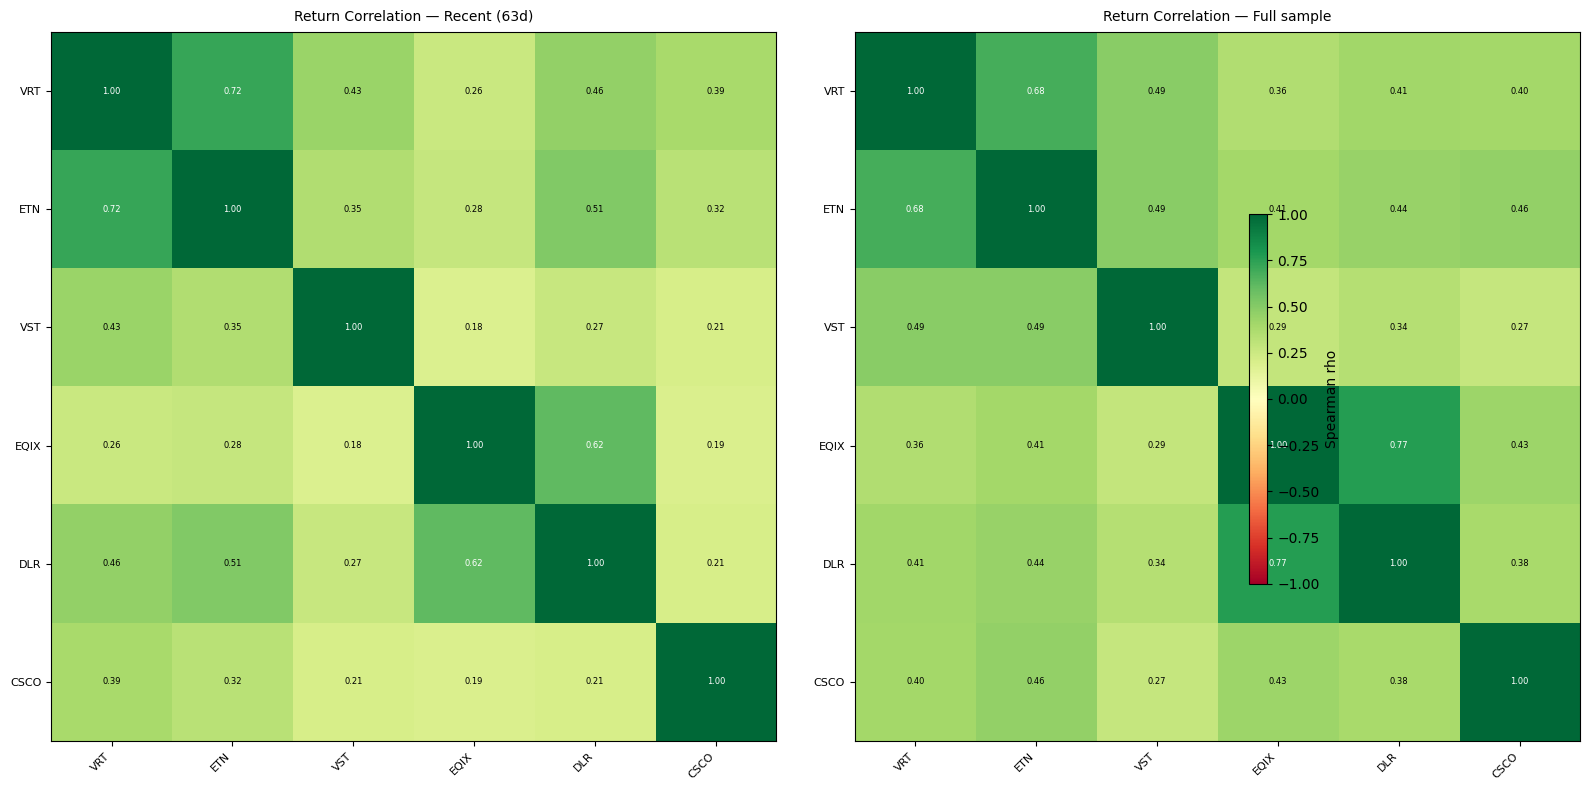

Saved: universe_correlation.png
Exported: universe_correlation_flags.csv, universe_correlation_recent.csv


In [48]:
# ── Cell 2.5: Universe Correlation Diagnostic (v2.3) ────────────────────────

ret = close[UNIVERSE].pct_change().dropna()
ret_recent = ret.iloc[-CORR_WINDOW:]
corr_recent = ret_recent.corr(method='spearman')
corr_full   = ret.corr(method='spearman')

N = len(UNIVERSE)

# N_effective from recent correlation matrix
N_eff     = round(N**2 / (corr_recent.values**2).sum(), 2)
N_eff_pct = round(N_eff / N * 100, 1)

# Flag pairs
flag_rows = []
for i, t1 in enumerate(UNIVERSE):
    for t2 in UNIVERSE[i+1:]:
        rho_r = corr_recent.loc[t1, t2]
        rho_f = corr_full.loc[t1, t2]
        if abs(rho_r) > CORR_GATE:
            flag = 'REDUNDANT'
        elif abs(rho_r) > 0.70:
            flag = 'ELEVATED'
        else:
            continue
        flag_rows.append({
            'Ticker_A': t1, 'Ticker_B': t2,
            'Corr_Recent': round(rho_r, 3),
            'Corr_Full':   round(rho_f, 3),
            'Flag': flag,
        })

flag_df = pd.DataFrame(flag_rows) if flag_rows else pd.DataFrame(
    columns=['Ticker_A','Ticker_B','Corr_Recent','Corr_Full','Flag'])

print('=== Universe Correlation Diagnostic ===')
print(f'N tickers : {N}')
print(f'N_eff     : {N_eff}  ({N_eff_pct}% of max)')
print(f'Window    : {CORR_WINDOW} trading days')
print(f'Gate      : rho > {CORR_GATE}')
print()
if flag_df.empty:
    print('No redundant pairs. Universe is well-diversified.')
else:
    print(flag_df.to_string(index=False))

# Advice
print()
if N_eff_pct < 40:
    print('CRITICAL: N_eff below 40%. Universe too correlated for reliable pooled IC.')
    print('Split into sub-universes of 5-8 names grouped by business model.')
elif N_eff_pct < 60:
    print('WARNING: Moderate redundancy. Sub-universe analysis recommended.')
    print('Run full universe for overview, then re-run on sub-clusters.')
elif N_eff_pct < 75:
    print('CAUTION: Some redundancy. Flagged pairs worth reviewing.')
else:
    print('Universe diversity acceptable for pooled analysis.')

# Heatmap
cell_sz = max(0.45, min(0.65, 8.0 / N))
fig_sz  = max(8, int(N * cell_sz) + 2)

fig, axes = plt.subplots(1, 2, figsize=(fig_sz * 2, fig_sz))
for ax, mat, title in [
    (axes[0], corr_recent, f'Recent ({CORR_WINDOW}d)'),
    (axes[1], corr_full,   'Full sample'),
]:
    im = ax.imshow(mat.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels(UNIVERSE, rotation=45, ha='right',
                       fontsize=max(5, 9 - N//5))
    ax.set_yticklabels(UNIVERSE, fontsize=max(5, 9 - N//5))
    ax.set_title(f'Return Correlation — {title}', fontsize=10, pad=8)
    for i in range(N):
        for j in range(N):
            v = mat.values[i, j]
            txt_color = 'white' if abs(v) > 0.6 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=max(4, 7 - N//6), color=txt_color)
    # Red boxes on redundant pairs
    for _, row in flag_df[flag_df['Flag'] == 'REDUNDANT'].iterrows():
        r = UNIVERSE.index(row['Ticker_A'])
        c = UNIVERSE.index(row['Ticker_B'])
        for ri, ci in [(r, c), (c, r)]:
            rect = plt.Rectangle((ci-0.5, ri-0.5), 1, 1,
                                  fill=False, edgecolor='red', linewidth=2.5)
            ax.add_patch(rect)

plt.colorbar(im, ax=axes.tolist(), shrink=0.6, label='Spearman rho')
plt.tight_layout()
plt.savefig(f'{FOLDER}/universe_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: universe_correlation.png')

# Export
flag_df.to_csv(f'{FOLDER}/universe_correlation_flags.csv', index=False)
corr_recent.to_csv(f'{FOLDER}/universe_correlation_recent.csv')
print('Exported: universe_correlation_flags.csv, universe_correlation_recent.csv')


## 3.2 Fundamental & Credit Data Pull

Pulls three additional data layers:
- **Short interest** from yfinance `.info` (monthly snapshot per ticker)
- **Earnings estimate revisions** from Financial Modeling Prep API (requires free API key)
- **Credit market data** from yfinance (HYG, LQD, ^IRX — no vendor needed)

If `FMP_API_KEY` is empty, FMP signals are skipped gracefully and flagged in output.

In [ ]:
# ── Cell 3.2: Fundamental & Credit Data Pull ────────────────────────────────

# ── Short Interest (yfinance .info snapshot) ─────────────────────────────────
print('Pulling short interest data...')
si_data = {}
for t in UNIVERSE:
    try:
        info = yf.Ticker(t).info
        si_data[t] = {
            'sharesShort'          : info.get('sharesShort', np.nan),
            'sharesOutstanding'    : info.get('sharesOutstanding', np.nan),
            'shortRatio'           : info.get('shortRatio', np.nan),  # days to cover
            'shortPercentOfFloat'  : info.get('shortPercentOfFloat', np.nan),
            'floatShares'          : info.get('floatShares', np.nan),
        }
        pct = si_data[t]['shortPercentOfFloat']
        pct_str = f'{pct*100:.1f}%' if pct and not np.isnan(pct) else 'n/a'
        ratio = si_data[t]['shortRatio']
        ratio_str = f'{ratio:.1f}d' if ratio and not np.isnan(ratio) else 'n/a'
        print(f'  {t}: SI%={pct_str}  DaysToCover={ratio_str}')
    except Exception as e:
        si_data[t] = {}
        print(f'  {t}: failed ({e})')

si_df = pd.DataFrame(si_data).T
print()

# Note: yfinance SI is a point-in-time snapshot, not a time series.
# We use it to construct static signals scored against forward returns.
# For a time-series SI signal, FINRA bi-monthly data or Ortex/S3 is needed (v3).

# ── Earnings Estimate Revisions (FMP API) ────────────────────────────────────
print('Pulling earnings estimate revisions...')
fmp_data = {}
FMP_AVAILABLE = bool(FMP_API_KEY)

if FMP_AVAILABLE:
    base = 'https://financialmodelingprep.com/api/v3'
    for t in UNIVERSE:
        try:
            # Analyst estimates endpoint
            url = f'{base}/analyst-estimates/{t}?limit=8&apikey={FMP_API_KEY}'
            r = requests.get(url, timeout=10)
            estimates = r.json()

            # EPS surprise history
            url2 = f'{base}/earnings-surprises/{t}?apikey={FMP_API_KEY}'
            r2 = requests.get(url2, timeout=10)
            surprises = r2.json()

            fmp_data[t] = {
                'estimates' : estimates[:4] if isinstance(estimates, list) else [],
                'surprises' : surprises[:4] if isinstance(surprises, list) else [],
            }
            n_est = len(fmp_data[t]['estimates'])
            n_sur = len(fmp_data[t]['surprises'])
            print(f'  {t}: {n_est} estimate periods, {n_sur} surprise records')
        except Exception as e:
            fmp_data[t] = {'estimates': [], 'surprises': []}
            print(f'  {t}: failed ({e})')
else:
    print('  FMP_API_KEY not set — skipping earnings revision signals.')
    print('  Get a free key at financialmodelingprep.com and paste into config.')
    for t in UNIVERSE:
        fmp_data[t] = {'estimates': [], 'surprises': []}

print()

# ── Credit Market Data (yfinance) ─────────────────────────────────────────────
print('Pulling credit market data...')
credit_raw = yf.download(CREDIT_TICKERS, start=START, end=END,
                          auto_adjust=True, progress=False)
credit_close = credit_raw['Close'].copy()
print(f'  Credit data shape: {credit_close.shape}')
print(f'  Columns: {list(credit_close.columns)}')
print()
print('Data pull complete.')

## 3. Signal Construction

Each function returns a DataFrame (index=dates, columns=PHOTONICS).
Positive = bullish, negative = bearish, zero = neutral.

In [49]:
# ── Tier 1: Price / Technical ───────────────────────────────────────────────

def sig_momentum(close, window):
    """n-day price momentum."""
    return close[PHOTONICS].pct_change(window)

def sig_volume_surge(volume, window=VOL_WINDOW):
    """Volume / rolling mean - 1. Positive = above average."""
    avg = volume[PHOTONICS].rolling(window).mean()
    return (volume[PHOTONICS] / avg) - 1

def sig_sma200_distance(close):
    """% distance from 200-day SMA."""
    sma = close[PHOTONICS].rolling(SMA_WINDOW).mean()
    return (close[PHOTONICS] - sma) / sma

def sig_ema_cross(close, fast=EMA_FAST, slow=EMA_SLOW):
    """(Fast EMA - Slow EMA) / price."""
    ema_f = close[PHOTONICS].ewm(span=fast).mean()
    ema_s = close[PHOTONICS].ewm(span=slow).mean()
    return (ema_f - ema_s) / close[PHOTONICS]

def sig_bollinger_position(close, window=BB_WINDOW, n_std=BB_STD):
    """%B centered at midline (0=mid, +0.5=upper, -0.5=lower)."""
    mid   = close[PHOTONICS].rolling(window).mean()
    std   = close[PHOTONICS].rolling(window).std()
    upper = mid + n_std * std
    lower = mid - n_std * std
    return (close[PHOTONICS] - lower) / (upper - lower) - 0.5

# ── Tier 2: Macro ────────────────────────────────────────────────────────────

def sig_vix_regime(close):
    """Binary regime: +1 if VIX < threshold."""
    regime = pd.Series(np.where(close['VIX'] < VIX_THRESHOLD, 1, -1), index=close.index)
    return pd.DataFrame({t: regime for t in PHOTONICS})

def sig_vix_change(close):
    """Inverted 1-day VIX return (falling VIX = bullish)."""
    r = -close['VIX'].pct_change(1)
    return pd.DataFrame({t: r for t in PHOTONICS})

def sig_sox_relative(close):
    """Ticker return minus SOX return."""
    return close[PHOTONICS].pct_change(1).subtract(close['SOX'].pct_change(1), axis=0)

def sig_tnx_change(close):
    """Inverted TNX change (rising rates = headwind)."""
    r = -close['TNX'].pct_change(1)
    return pd.DataFrame({t: r for t in PHOTONICS})

def sig_oil_change(close):
    """USO daily return."""
    r = close['USO'].pct_change(1)
    return pd.DataFrame({t: r for t in PHOTONICS})

def sig_spx_relative(close):
    """Ticker return minus SPX return."""
    return close[PHOTONICS].pct_change(1).subtract(close['SPX'].pct_change(1), axis=0)

def sig_sox_vs_spx(close):
    """SOX return minus SPX return — sector leadership signal."""
    spread = close['SOX'].pct_change(1) - close['SPX'].pct_change(1)
    return pd.DataFrame({t: spread for t in PHOTONICS})

print('Signal functions defined.')

Signal functions defined.


## 3.3 Tier 3/4/5 Signal Construction

### Tier 3 — Short Interest
- `SI_Ratio`: short interest as % of float (static score, cross-sectional rank)
- `SI_DaysToCover`: days-to-cover ratio (higher = harder to cover = squeeze risk)
- `SI_Momentum`: interaction signal — high SI + positive price momentum = squeeze setup

### Tier 4 — Earnings Estimate Revisions
- `EPS_Revision_Dir`: direction of most recent estimate revision (+1 up, -1 down, 0 flat)
- `EPS_Surprise_Avg`: average EPS surprise over last 4 quarters (positive = beat history)

### Tier 5 — Credit Market
- `CreditSpread`: HYG/LQD price ratio change (falling ratio = widening spreads = risk-off)
- `CreditSpread_Change`: 5-day change in credit spread — leading indicator vs VIX
- `YieldCurve_Slope`: TNX minus IRX (10Y minus 3M) — steepening = risk-on, inversion = risk-off

In [ ]:
# ── Cell 3.3: Tier 3/4/5 Signal Construction ────────────────────────────────

# ── Tier 3: Short Interest ───────────────────────────────────────────────────

def sig_si_ratio(si_df, close):
    """
    Short interest as % of float, cross-sectionally ranked.
    High SI = potential squeeze fuel = positive score when price rises.
    Static signal — same value broadcast across all dates.
    Cross-sectional rank so universe size doesn't affect magnitude.
    """
    si_pct = {}
    for t in UNIVERSE:
        val = si_df.loc[t, 'shortPercentOfFloat'] if t in si_df.index else np.nan
        si_pct[t] = val if pd.notna(val) else 0.0

    # Rank across universe (percentile)
    vals = np.array([si_pct[t] for t in UNIVERSE], dtype=float)
    ranked = rankdata(vals) / len(vals)
    ranked_dict = {t: ranked[i] for i, t in enumerate(UNIVERSE)}

    # Broadcast static score across all dates
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = ranked_dict[t]
    return result

def sig_si_days_to_cover(si_df, close):
    """
    Days-to-cover (short ratio). Higher = more sessions needed to unwind shorts.
    Scaled to [0,1] across universe. High DTC = squeeze risk amplifier.
    """
    dtc = {}
    for t in UNIVERSE:
        val = si_df.loc[t, 'shortRatio'] if t in si_df.index else np.nan
        dtc[t] = val if pd.notna(val) else 0.0

    vals = np.array([dtc[t] for t in UNIVERSE], dtype=float)
    ranked = rankdata(vals) / len(vals)
    ranked_dict = {t: ranked[i] for i, t in enumerate(UNIVERSE)}

    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = ranked_dict[t]
    return result

def sig_si_momentum_interaction(si_df, close, momentum_window=10):
    """
    Interaction signal: high short interest × positive momentum.
    Captures squeeze setup — rising price into a crowded short.
    Score = SI_percentile × sign(momentum). Positive = squeeze candidate.
    """
    si_pct = {}
    for t in UNIVERSE:
        val = si_df.loc[t, 'shortPercentOfFloat'] if t in si_df.index else np.nan
        si_pct[t] = val if pd.notna(val) else 0.0

    vals = np.array([si_pct[t] for t in UNIVERSE], dtype=float)
    ranked = rankdata(vals) / len(vals)
    si_ranked = {t: ranked[i] for i, t in enumerate(UNIVERSE)}

    mom = close[UNIVERSE].pct_change(momentum_window)
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = si_ranked[t] * np.sign(mom[t])
    return result

# ── Tier 4: Earnings Estimate Revisions ─────────────────────────────────────

def sig_eps_revision_direction(fmp_data, close):
    """
    Direction of most recent EPS estimate revision.
    +1 = estimate raised, -1 = estimate cut, 0 = no data / flat.
    Static signal broadcast across dates (updates when FMP data refreshes).
    """
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        estimates = fmp_data[t].get('estimates', [])
        if len(estimates) >= 2:
            # Compare most recent two estimate periods
            try:
                curr = float(estimates[0].get('estimatedEpsAvg', 0) or 0)
                prev = float(estimates[1].get('estimatedEpsAvg', 0) or 0)
                direction = np.sign(curr - prev)
            except (TypeError, ValueError):
                direction = 0.0
        else:
            direction = 0.0
        result[t] = direction
    return result

def sig_eps_surprise_avg(fmp_data, close):
    """
    Average EPS surprise (actual vs estimated) over last 4 quarters.
    Positive = company consistently beats estimates = quality signal.
    Normalized by absolute estimate to make comparable across price levels.
    """
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        surprises = fmp_data[t].get('surprises', [])
        surprise_vals = []
        for s in surprises[:4]:
            try:
                actual = float(s.get('actualEarningResult', 0) or 0)
                est    = float(s.get('estimatedEarning', 0) or 0)
                if est != 0:
                    surprise_vals.append((actual - est) / abs(est))
            except (TypeError, ValueError):
                continue
        avg_surprise = np.mean(surprise_vals) if surprise_vals else 0.0
        # Clip to [-1, 1] to prevent outliers dominating
        result[t] = np.clip(avg_surprise, -1.0, 1.0)
    return result

# ── Tier 5: Credit Market ────────────────────────────────────────────────────

def sig_credit_spread(credit_close, close):
    """
    HYG/LQD price ratio — proxy for credit spread direction.
    Rising ratio = spread tightening = risk-on = bullish.
    Falling ratio = spread widening = risk-off = bearish.
    21-day rate of change of ratio.
    """
    if 'HYG' not in credit_close.columns or 'LQD' not in credit_close.columns:
        # Return zero signal if data unavailable
        return pd.DataFrame(0.0, index=close.index, columns=UNIVERSE)

    ratio = credit_close['HYG'] / credit_close['LQD']
    spread_signal = ratio.pct_change(21)  # 21d trend in ratio
    spread_aligned = spread_signal.reindex(close.index).ffill()

    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = spread_aligned
    return result

def sig_credit_spread_change(credit_close, close):
    """
    5-day change in HYG/LQD ratio — faster credit signal.
    Leads VIX by 2-5 days in risk-off episodes.
    """
    if 'HYG' not in credit_close.columns or 'LQD' not in credit_close.columns:
        return pd.DataFrame(0.0, index=close.index, columns=UNIVERSE)

    ratio = credit_close['HYG'] / credit_close['LQD']
    spread_chg = ratio.pct_change(5)
    spread_aligned = spread_chg.reindex(close.index).ffill()

    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = spread_aligned
    return result

def sig_yield_curve_slope(credit_close, close):
    """
    10Y (TNX) minus 3M (IRX) yield spread.
    Steepening = risk-on, inversion = recession signal / risk-off.
    Uses TNX from main close df, IRX from credit_close.
    """
    tnx = close['TNX'].reindex(close.index)

    if 'IRX' in credit_close.columns:
        irx = credit_close['IRX'].reindex(close.index).ffill()
    else:
        # Fallback: approximate 3M with a flat 4.0% if not available
        irx = pd.Series(4.0, index=close.index)

    slope = (tnx - irx).reindex(close.index).ffill()

    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = slope
    return result

print('Tier 3/4/5 signal functions defined.')
print()
print('Signals available:')
print('  Tier 3 (Short Interest): SI_Ratio, SI_DaysToCover, SI_Momentum')
print('  Tier 4 (Earnings):       EPS_Revision_Dir, EPS_Surprise_Avg')
print('  Tier 5 (Credit):         CreditSpread, CreditSpread_Change, YieldCurve_Slope')

In [50]:
signals = {
    # ── Tier 1: Price / Technical ────────────────────────────────────────────
    'Momentum_5d'     : sig_momentum(close, 5),
    'Momentum_10d'    : sig_momentum(close, 10),
    'Momentum_21d'    : sig_momentum(close, 21),
    'Volume_Surge'    : sig_volume_surge(volume),
    'SMA200_Distance' : sig_sma200_distance(close),
    'EMA_Cross_9_21'  : sig_ema_cross(close),
    'Bollinger_Pct_B' : sig_bollinger_position(close),
    # ── Tier 2: Macro ────────────────────────────────────────────────────────
    'VIX_Regime'      : sig_vix_regime(close),
    'VIX_Change_1d'   : sig_vix_change(close),
    'SOX_Relative'    : sig_sox_relative(close),
    'TNX_Change'      : sig_tnx_change(close),
    'Oil_Change'      : sig_oil_change(close),
    'SPX_Relative'    : sig_spx_relative(close),
    'SOX_vs_SPX'      : sig_sox_vs_spx(close),
    # ── Tier 3: Short Interest ────────────────────────────────────────────────
    'SI_Ratio'        : sig_si_ratio(si_df, close),
    'SI_DaysToCover'  : sig_si_days_to_cover(si_df, close),
    'SI_Momentum'     : sig_si_momentum_interaction(si_df, close),
    # ── Tier 4: Earnings Estimate Revisions ───────────────────────────────────
    'EPS_Revision_Dir': sig_eps_revision_direction(fmp_data, close),
    'EPS_Surprise_Avg': sig_eps_surprise_avg(fmp_data, close),
    # ── Tier 5: Credit Market ─────────────────────────────────────────────────
    'CreditSpread'       : sig_credit_spread(credit_close, close),
    'CreditSpread_Change': sig_credit_spread_change(credit_close, close),
    'YieldCurve_Slope'   : sig_yield_curve_slope(credit_close, close),
}

print(f'{len(signals)} signals built:')
tier_map = {
    'Tier 1 Price'    : ['Momentum_5d','Momentum_10d','Momentum_21d',
                         'Volume_Surge','SMA200_Distance','EMA_Cross_9_21',
                         'Bollinger_Pct_B'],
    'Tier 2 Macro'    : ['VIX_Regime','VIX_Change_1d','SOX_Relative',
                         'TNX_Change','Oil_Change','SPX_Relative','SOX_vs_SPX'],
    'Tier 3 ShortInt' : ['SI_Ratio','SI_DaysToCover','SI_Momentum'],
    'Tier 4 Earnings' : ['EPS_Revision_Dir','EPS_Surprise_Avg'],
    'Tier 5 Credit'   : ['CreditSpread','CreditSpread_Change','YieldCurve_Slope'],
}
for tier, sigs in tier_map.items():
    present = [s for s in sigs if s in signals]
    print(f'  {tier}: {present}')

14 signals built:
  Momentum_5d
  Momentum_10d
  Momentum_21d
  Volume_Surge
  SMA200_Distance
  EMA_Cross_9_21
  Bollinger_Pct_B
  VIX_Regime
  VIX_Change_1d
  SOX_Relative
  TNX_Change
  Oil_Change
  SPX_Relative
  SOX_vs_SPX


## 4. v1 IC Baseline (Spearman, raw signals)

Retained from v1 for comparison. v2 IC (post-demeaning) computed in Section 6.

In [51]:
def compute_ic(signal_df, close, ticker, horizon):
    fwd_ret = close[ticker].pct_change(horizon).shift(-horizon)
    sig     = signal_df[ticker]
    df      = pd.concat([sig, fwd_ret], axis=1).dropna()
    df.columns = ['signal', 'fwd_ret']
    if len(df) < 30:
        return np.nan, np.nan
    return spearmanr(df['signal'], df['fwd_ret'])

rows = []
for sig_name, sig_df in signals.items():
    for ticker in PHOTONICS:
        for h in HORIZONS:
            ic, pval = compute_ic(sig_df, close, ticker, h)
            rows.append({'Signal':sig_name,'Ticker':ticker,'Horizon':h,
                         'IC':ic,'p_value':pval,'Sig_05':pval<0.05 if not np.isnan(pval) else False})

ic_df = pd.DataFrame(rows)

summary = (ic_df.groupby(['Signal','Horizon'])
           .agg(Mean_IC=('IC','mean'),
                Mean_AbsIC=('IC', lambda x: x.abs().mean()),
                Pct_Sig=('Sig_05','mean'))
           .reset_index())

best_horizon = (summary.loc[summary.groupby('Signal')['Mean_AbsIC'].idxmax()]
                .rename(columns={'Horizon':'Optimal_Horizon'})
                .sort_values('Mean_AbsIC', ascending=False)
                .reset_index(drop=True))

print('=== v1 Signals ranked by peak |IC| ===')
print(best_horizon[['Signal','Optimal_Horizon','Mean_IC','Mean_AbsIC','Pct_Sig']].to_string(index=False))

=== v1 Signals ranked by peak |IC| ===
         Signal  Optimal_Horizon   Mean_IC  Mean_AbsIC  Pct_Sig
SMA200_Distance               21 -0.130960    0.155238 0.833333
 EMA_Cross_9_21               21  0.024969    0.065024 0.500000
   Momentum_21d               21  0.018478    0.064059 0.500000
    Momentum_5d                3 -0.063338    0.063338 0.166667
     VIX_Regime               21  0.030142    0.062221 0.500000
   Volume_Surge               21  0.012041    0.049569 0.500000
Bollinger_Pct_B               21  0.029927    0.045148 0.333333
     TNX_Change                5  0.040237    0.040237 0.166667
     Oil_Change                5 -0.026695    0.039945 0.333333
   SPX_Relative                5 -0.039694    0.039694 0.000000
   Momentum_10d               21  0.032642    0.035357 0.166667
     SOX_vs_SPX                5 -0.009241    0.034174 0.166667
   SOX_Relative                5 -0.029578    0.029578 0.000000
  VIX_Change_1d               21 -0.024565    0.026073 0.000000


---
## PART II — Alpha Combination Engine
### 11-Step Institutional Procedure (rohonchain framework)

Steps 2–11 implement the full weight optimization pipeline.
Each step's output feeds directly into the next.

### Step 2 — Serial Demeaning

`X(i,s) = R(i,s) − mean_s[R(i,s)]`

Removes systematic drift so a signal that happened to be long during
a bull market doesn't receive inflated weight. After this step every
signal series has mean exactly zero.

In [52]:
X = {}  # demeaned signal values
demean_log = []

for sig_name, sig_df in signals.items():
    raw      = sig_df[PHOTONICS].copy()
    mean_r   = raw.mean()
    X[sig_name] = raw.subtract(mean_r, axis='columns')

    for t in PHOTONICS:
        demean_log.append({
            'Signal'    : sig_name,
            'Ticker'    : t,
            'Pre_mean'  : round(mean_r[t], 6),
            'Post_mean' : round(X[sig_name][t].mean(), 10),
            'M_obs'     : int(raw[t].count()),
        })

demean_df = pd.DataFrame(demean_log)

drift_summary = (demean_df.groupby('Signal')
                 .agg(Avg_PreMean=('Pre_mean', lambda x: x.abs().mean()),
                      M_obs=('M_obs','mean'))
                 .sort_values('Avg_PreMean', ascending=False))

print('=== Step 2: Drift removed (sorted by magnitude) ===')
print(drift_summary.to_string())
print()
max_resid = demean_df['Post_mean'].abs().max()
print(f'Max residual mean: {max_resid:.2e}  [{"PASS" if max_resid < 1e-8 else "CHECK"}]')

=== Step 2: Drift removed (sorted by magnitude) ===
                 Avg_PreMean   M_obs
Signal                              
VIX_Regime          0.265421  1070.0
SMA200_Distance     0.152565   871.0
Bollinger_Pct_B     0.067222  1051.0
Momentum_21d        0.028207  1049.0
Momentum_10d        0.012806  1060.0
Volume_Surge        0.009713  1061.0
Momentum_5d         0.006455  1065.0
EMA_Cross_9_21      0.004030  1070.0
VIX_Change_1d       0.003041  1069.0
TNX_Change          0.001082  1069.0
Oil_Change          0.001038  1069.0
SPX_Relative        0.000929  1069.0
SOX_Relative        0.000879  1069.0
SOX_vs_SPX          0.000607  1069.0

Max residual mean: 0.00e+00  [PASS]


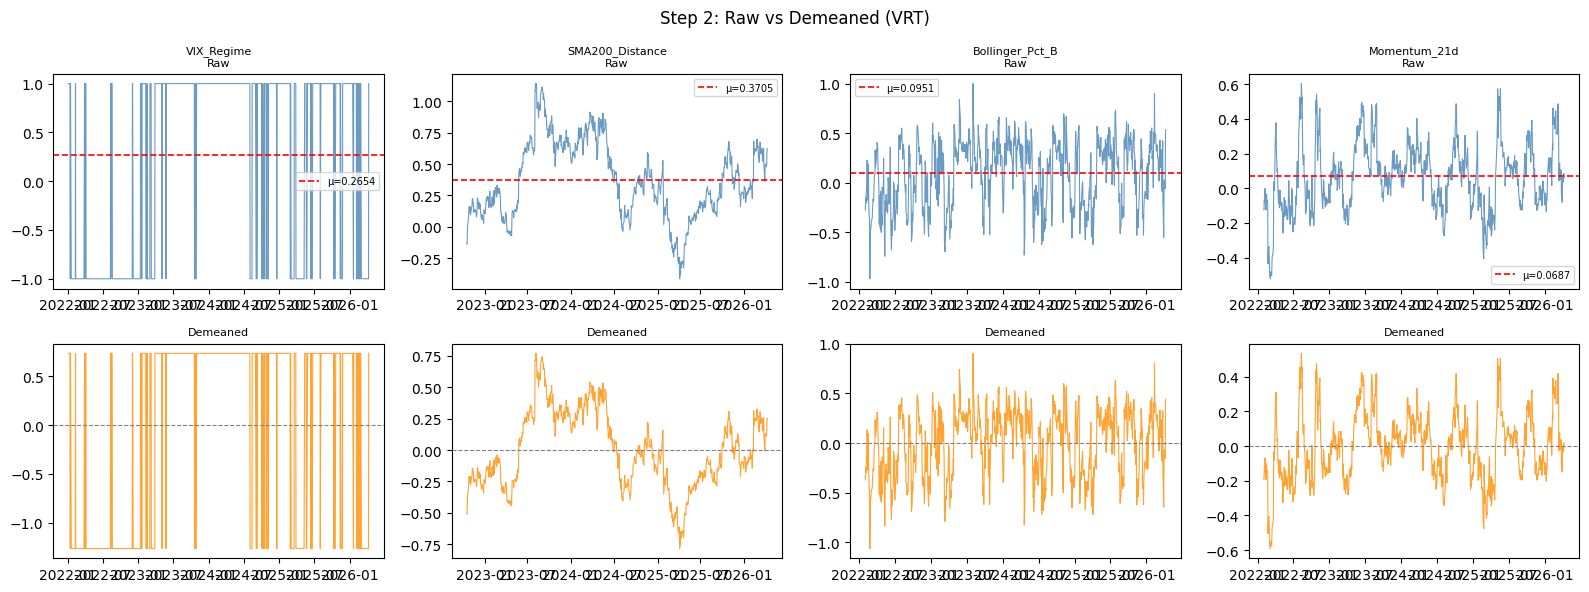

Saved: step2_demean.png


In [53]:
# Visualize: raw vs demeaned for 4 highest-drift signals (first ticker in universe)
VIZ_TICKER = UNIVERSE[0]
top4 = drift_summary.head(4).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle(f'Step 2: Raw vs Demeaned ({VIZ_TICKER})', fontsize=12)

for col, sig in enumerate(top4):
    raw_s = signals[sig][VIZ_TICKER].dropna()
    dm_s  = X[sig][VIZ_TICKER].dropna()
    axes[0,col].plot(raw_s.index, raw_s.values, color='steelblue', lw=0.8, alpha=0.8)
    axes[0,col].axhline(raw_s.mean(), color='red', lw=1.2, ls='--', label=f'μ={raw_s.mean():.4f}')
    axes[0,col].set_title(f'{sig}\nRaw', fontsize=8)
    axes[0,col].legend(fontsize=7)
    axes[1,col].plot(dm_s.index, dm_s.values, color='darkorange', lw=0.8, alpha=0.8)
    axes[1,col].axhline(0, color='gray', lw=0.8, ls='--')
    axes[1,col].set_title('Demeaned', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FOLDER}/step2_demean.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step2_demean.png')

### Step 3 — Sample Variance

`σ²(i) = (1/M) × Σ X(i,s)²`

Measures how volatile each signal's demeaned returns are.
High variance = noisy signal. Used in Step 4 (normalization) and Step 10 (weighting).

In [54]:
sigma2 = {}  # variance per signal × ticker
sigma  = {}  # std dev per signal × ticker

var_log = []
for sig_name in signals:
    sig_x = X[sig_name][PHOTONICS].dropna()
    M     = len(sig_x)
    var   = (sig_x ** 2).sum() / M   # Series per ticker
    std   = np.sqrt(var)
    sigma2[sig_name] = var
    sigma[sig_name]  = std
    for t in PHOTONICS:
        var_log.append({'Signal':sig_name,'Ticker':t,
                        'Variance':var[t],'StdDev':std[t],'M':M})

var_df = pd.DataFrame(var_log)

print('=== Step 3: Sample Variance per Signal × Ticker ===')
pivot_std = var_df.pivot(index='Signal', columns='Ticker', values='StdDev').round(6)
print(pivot_std.to_string())

=== Step 3: Sample Variance per Signal × Ticker ===
Ticker               CSCO       DLR      EQIX       ETN       VRT       VST
Signal                                                                     
Bollinger_Pct_B  0.318329  0.327588  0.323033  0.327456  0.323869  0.319557
EMA_Cross_9_21   0.013987  0.018967  0.017873  0.018455  0.047931  0.030050
Momentum_10d     0.042131  0.054967  0.053051  0.055059  0.126485  0.094880
Momentum_21d     0.060175  0.078882  0.076885  0.080994  0.191710  0.145087
Momentum_5d      0.032611  0.040209  0.037413  0.039732  0.090680  0.064718
Oil_Change       0.022454  0.022454  0.022454  0.022454  0.022454  0.022454
SMA200_Distance  0.080191  0.113397  0.087624  0.113683  0.304845  0.291046
SOX_Relative     0.020607  0.022080  0.022835  0.017507  0.031897  0.028943
SOX_vs_SPX       0.015602  0.015602  0.015602  0.015602  0.015602  0.015602
SPX_Relative     0.012195  0.015548  0.014984  0.014287  0.035676  0.027977
TNX_Change       0.018680  0.018680 

### Step 4 — Standardization

`Y(i,s) = X(i,s) / σ(i)`

Puts all signals on the same scale regardless of original units.
Momentum (% return) and VIX (index points change) become directly comparable.

In [55]:
Y = {}  # standardized signals

for sig_name in signals:
    std_vals = sigma[sig_name]  # Series per ticker
    Y[sig_name] = X[sig_name].divide(std_vals, axis='columns')

# Verify: std of Y should be ~1.0 per ticker
print('=== Step 4: Post-standardization std (should be ~1.0) ===')
std_check = pd.DataFrame({
    sig: Y[sig][PHOTONICS].std()
    for sig in signals
}).T.round(4)
print(std_check.to_string())

=== Step 4: Post-standardization std (should be ~1.0) ===
                    VRT     ETN     VST    EQIX     DLR    CSCO
Momentum_5d      1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
Momentum_10d     1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
Momentum_21d     1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
Volume_Surge     1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
SMA200_Distance  1.0006  1.0006  1.0006  1.0006  1.0006  1.0006
EMA_Cross_9_21   1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
Bollinger_Pct_B  1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
VIX_Regime       1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
VIX_Change_1d    1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
SOX_Relative     1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
TNX_Change       1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
Oil_Change       1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
SPX_Relative     1.0005  1.0005  1.0005  1.0005  1.0005  1.0005
SOX_vs_SPX       1.0005  1.0005  1.0005  1.000

### Step 5 — Drop Most Recent Observation

Retain only periods 1 through M-1. Ensures weight calculation uses
purely historical data with no look-ahead contamination.

In [56]:
Y_hist = {}

for sig_name in signals:
    df = Y[sig_name].dropna()
    Y_hist[sig_name] = df.iloc[:-1]   # drop last row

sample_sig = list(signals.keys())[0]
print(f'Full Y rows:      {len(Y[sample_sig].dropna())}')
print(f'Historical Y rows:{len(Y_hist[sample_sig])}  (one dropped)')

Full Y rows:      1065
Historical Y rows:1064  (one dropped)


### Step 6 — Cross-Sectional Demeaning

`Λ(i,s) = Y(i,s) − mean_i[Y(i,s)]`

At each time period s, subtract the average standardized value across
all N signals. This removes any market-wide effect simultaneously
driving all signals in the same direction — isolating each signal's
idiosyncratic contribution.

In [57]:
# Stack all signals into a single panel: index=date, columns=signal names
# One panel per ticker, then cross-sectionally demean across signals

Lambda = {}   # cross-sectionally demeaned: {ticker: DataFrame[signal × date]}

for t in PHOTONICS:
    # Build date × signal matrix for this ticker
    ticker_panel = pd.DataFrame({
        sig: Y_hist[sig][t]
        for sig in signals
    }).dropna()

    # At each date (row), subtract mean across signals (columns)
    cross_mean = ticker_panel.mean(axis=1)   # mean across signals at each date
    Lambda[t]  = ticker_panel.subtract(cross_mean, axis=0)

# Verify: mean across signals at each date should be ~0
sample_ticker = UNIVERSE[0]
row_means = Lambda[sample_ticker].mean(axis=1).abs().max()
print(f'=== Step 6 Complete ===')
print(f'Cross-sectional mean residual ({sample_ticker}, max): {row_means:.2e}  [{"PASS" if row_means < 1e-10 else "CHECK"}]')
print(f'Panel shape per ticker: {Lambda[sample_ticker].shape}  (dates × signals)')

=== Step 6 Complete ===
Cross-sectional mean residual (VRT, max): 4.60e-16  [PASS]
Panel shape per ticker: (870, 14)  (dates × signals)


### Step 7 — Drop Final Period

Secondary data hygiene step: remove the last remaining observation
from Λ to eliminate any residual look-ahead information.

In [58]:
Lambda_hist = {t: Lambda[t].iloc[:-1] for t in PHOTONICS}

sample_t = UNIVERSE[0]
print(f'Λ rows after Step 6: {len(Lambda[sample_t])}')
print(f'Λ rows after Step 7: {len(Lambda_hist[sample_t])}')

Λ rows after Step 6: 870
Λ rows after Step 7: 869


### Step 8 — Expected Forward Return (Normalized)

`E(i) = (1/d) × Σ R(i,s) over most recent d periods`
`E_norm(i) = E(i) / σ(i)`

d-day moving average of each signal's actual forward returns,
normalized by its standard deviation. This is the forward-looking
estimate of each signal's expected contribution.

In [59]:
# Use optimal horizon per signal from v1 IC results as forward return window
opt_h = best_horizon.set_index('Signal')['Optimal_Horizon'].to_dict()

E_norm = {}   # {sig_name: Series per ticker} — normalized expected return

for sig_name in signals:
    h   = int(opt_h[sig_name])
    ev  = {}
    for t in PHOTONICS:
        # Realized forward returns at this signal's optimal horizon
        fwd = close[t].pct_change(h).shift(-h)
        # d-day moving average of forward returns
        e_raw = fwd.rolling(D_LOOKBACK).mean()
        # Normalize by signal std
        ev[t] = e_raw / sigma[sig_name][t]
    E_norm[sig_name] = pd.DataFrame(ev)

# Show most recent expected return per signal
latest = close.index[-1]
e_latest = {}
for sig_name in signals:
    row = E_norm[sig_name].dropna()
    if len(row) > 0:
        e_latest[sig_name] = row.iloc[-1]

e_latest_df = pd.DataFrame(e_latest).T
print('=== Step 8: Most Recent Normalized Expected Return per Signal × Ticker ===')
print(e_latest_df.round(4).to_string())

=== Step 8: Most Recent Normalized Expected Return per Signal × Ticker ===
                    VRT     ETN     VST    EQIX     DLR    CSCO
Momentum_5d      0.1312  0.3257 -0.0928  0.2881  0.1561  0.3145
Momentum_10d     0.6140 -0.3460 -0.6926  0.9651  0.2880  0.0965
Momentum_21d     0.4051 -0.2352 -0.4529  0.6659  0.2007  0.0676
Volume_Surge     0.1523 -0.0542 -0.1537  0.1356  0.0411  0.0109
SMA200_Distance  0.2547 -0.1676 -0.2258  0.5843  0.1396  0.0507
EMA_Cross_9_21   1.6202 -1.0322 -2.1868  2.8648  0.8348  0.2908
Bollinger_Pct_B  0.2398 -0.0582 -0.2056  0.1585  0.0483  0.0128
VIX_Regime       0.0805 -0.0198 -0.0682  0.0531  0.0164  0.0042
VIX_Change_1d    0.9845 -0.2415 -0.8330  0.6491  0.2007  0.0516
SOX_Relative     0.4785  0.8691 -0.4863  0.6790  0.3348  0.4895
TNX_Change       0.8172  0.8146 -0.7535  0.8301  0.3957  0.5401
Oil_Change       0.6798  0.6776 -0.6269  0.6905  0.3292  0.4493
SPX_Relative     0.4279  1.0650 -0.5031  1.0348  0.4754  0.8272
SOX_vs_SPX       0.9783  0.97

### Step 9 — Residual Regression (Independence Extraction)

For each signal i, regress E_norm(i) on Λ(i) without intercept.
The residual ε(i) is the component of each signal's expected return
that is **genuinely independent** — not explained by any pattern
shared across the full signal stack.

This is the critical step: not which signal has highest expected return,
but which contributes the most information no other signal already captures.

In [60]:
from sklearn.linear_model import LinearRegression
import warnings

epsilon = {}   # residuals per signal per ticker
regression_log = []

for sig_name in signals:
    eps_per_ticker = {}
    for t in PHOTONICS:
        try:
            # Align Lambda_hist and E_norm on common dates
            lam = Lambda_hist[t][sig_name].dropna()
            e   = E_norm[sig_name][t].dropna()
            common = lam.index.intersection(e.index)

            if len(common) < 30:
                eps_per_ticker[t] = pd.Series(dtype=float)
                continue

            lam_c = lam.loc[common].values.reshape(-1, 1)
            e_c   = e.loc[common].values

            # OLS without intercept (unit weights as per procedure)
            reg = LinearRegression(fit_intercept=False)
            reg.fit(lam_c, e_c)
            resid = e_c - reg.predict(lam_c)

            eps_per_ticker[t] = pd.Series(resid, index=common)
            regression_log.append({
                'Signal' : sig_name,
                'Ticker' : t,
                'Beta'   : round(reg.coef_[0], 6),
                'R2'     : round(reg.score(lam_c, e_c), 6),
                'N'      : len(common),
                'Eps_std': round(resid.std(), 6),
            })
        except Exception as ex:
            eps_per_ticker[t] = pd.Series(dtype=float)

    epsilon[sig_name] = eps_per_ticker

reg_df = pd.DataFrame(regression_log)
print('=== Step 9: Regression Summary (E_norm ~ Lambda) ===')
print('R² tells us how much of expected return is explained by shared signal variance.')
print('Low R² = more independent contribution (good).')
print()
r2_pivot = reg_df.pivot(index='Signal', columns='Ticker', values='R2').round(4)
print(r2_pivot.to_string())

=== Step 9: Regression Summary (E_norm ~ Lambda) ===
R² tells us how much of expected return is explained by shared signal variance.
Low R² = more independent contribution (good).

Ticker             CSCO     DLR    EQIX     ETN     VRT     VST
Signal                                                         
Bollinger_Pct_B  0.1342  0.2094  0.1996  0.1840 -0.0655 -0.1285
EMA_Cross_9_21   0.0069  0.0541  0.0591  0.0739 -0.1539 -0.0350
Momentum_10d     0.0403  0.1361  0.2677  0.1202 -0.1410  0.0357
Momentum_21d     0.0262  0.1063  0.1152  0.0722 -0.1243 -0.0494
Momentum_5d     -0.1249 -0.0606 -0.0289 -0.1075 -0.3081 -0.1625
Oil_Change      -0.0601 -0.0003  0.0231 -0.0124 -0.2463 -0.0570
SMA200_Distance -0.2007 -0.0975 -0.0360 -0.1664 -0.4028 -0.2397
SOX_Relative    -0.1246 -0.0382 -0.0071 -0.0618 -0.3010 -0.1223
SOX_vs_SPX      -0.0980 -0.0424 -0.0070 -0.0755 -0.2712 -0.0799
SPX_Relative    -0.1517 -0.0731 -0.0408 -0.1069 -0.3100 -0.1376
TNX_Change      -0.0666 -0.0004  0.0151 -0.0082 -0.

### Steps 10 & 11 — Signal Weights + Normalization

`w(i) = η × ε(i) / σ(i)`

Weight is proportional to independent edge (ε) and inversely
proportional to noise (σ). η normalizes so Σ|w(i)| = 1.

In [61]:
# ── Steps 10 & 11: Signal Weights + Normalization (v2.2) ────────────────────
#
# v2.2 fix: ε rank-normalization
#   In v2.1, EMA_Cross absorbed 81-84% of weight because its raw residuals
#   (ε ~34-49) dwarfed all other signals (ε ~0.1-2.0). This was a scale
#   artifact, not evidence of superior independent edge.
#
#   Fix: map each signal's ε series to percentile rank [0,1] within its
#   own distribution before computing w_raw. All signals now compete on
#   equal footing. A signal with consistently high-percentile residuals
#   receives high weight; scale is irrelevant.
#
# v2.2 fix: TICKER_SIGNAL_OVERRIDES map
#   Sign flips for specific ticker × signal × regime combinations are
#   now driven by the config table, not hardcoded if-statements.

from scipy.stats import rankdata

# Current regime
latest_vix = close['VIX'].dropna().iloc[-1]
latest_tnx = close['TNX'].dropna().iloc[-1]
current_regime = ('active' if (latest_vix < VIX_THRESHOLD and
                               latest_tnx < TNX_THRESHOLD) else 'risk_off')

print(f'Current VIX: {latest_vix:.2f}  TNX: {latest_tnx:.2f}%')
print(f'Current regime: {current_regime.upper()}')
print()

# Regime masks
active_mask   = ((close['VIX'] < VIX_THRESHOLD) &
                 (close['TNX'] < TNX_THRESHOLD))
risk_off_mask = ~active_mask

def rank_normalize(series):
    """Map series values to percentile rank [0, 1]."""
    if len(series) == 0:
        return series
    return pd.Series(
        rankdata(series) / len(series),
        index=series.index
    )

def compute_weights_for_regime(regime_mask, label):
    """
    Compute normalized signal weights for a given regime.
    Uses ε rank-normalization (Fix 4) and override map (Fix 6).
    Culled signals (not in KEEP_SIGNALS) receive w=0.
    """
    weight_log = []

    for sig_name in signals:
        for t in UNIVERSE:

            # Fix 1 (v2.1): Zero weight for culled signals
            if sig_name not in KEEP_SIGNALS:
                weight_log.append({
                    'Signal': sig_name, 'Ticker': t, 'Regime': label,
                    'w_raw': 0.0, 'w_norm': 0.0, 'culled': True
                })
                continue

            eps_series = epsilon[sig_name].get(t, pd.Series(dtype=float))
            if len(eps_series) == 0:
                weight_log.append({
                    'Signal': sig_name, 'Ticker': t, 'Regime': label,
                    'w_raw': np.nan, 'w_norm': np.nan, 'culled': False
                })
                continue

            # Filter epsilon to regime dates
            regime_dates = close.index[
                regime_mask.reindex(close.index).fillna(False)
            ]
            eps_regime = eps_series[eps_series.index.isin(regime_dates)]

            if len(eps_regime) < 10:
                w_raw = 0.0
            else:
                # Fix 4 (v2.2): rank-normalize ε before computing weight
                eps_ranked = rank_normalize(eps_regime)
                w_raw = eps_ranked.mean() / sigma[sig_name][t]

            # Fix 6 (v2.2): apply override sign from config map
            override_sign = TICKER_SIGNAL_OVERRIDES.get(
                (sig_name, t, label), +1
            )
            w_raw = override_sign * abs(w_raw) if w_raw != 0 else 0.0

            weight_log.append({
                'Signal': sig_name, 'Ticker': t, 'Regime': label,
                'w_raw': w_raw, 'w_norm': np.nan, 'culled': False
            })

    df = pd.DataFrame(weight_log)

    # Step 11: normalize per ticker, non-culled only
    def normalize(group):
        group = group.copy()
        total = group.loc[~group['culled'], 'w_raw'].abs().sum()
        group['w_norm'] = group['w_raw'].apply(
            lambda x: x / total if total > 0 else 0.0
        )
        return group

    df = df.groupby('Ticker', group_keys=False).apply(normalize)
    return df

# Compute both regimes
weights_active   = compute_weights_for_regime(active_mask,   'active')
weights_risk_off = compute_weights_for_regime(risk_off_mask, 'risk_off')
weight_df        = pd.concat([weights_active, weights_risk_off],
                              ignore_index=True)

# Current regime weights for downstream
weights_current  = weight_df[weight_df['Regime'] == current_regime].copy()

print('=== Steps 10–11: Normalized Weights (current regime) ===')
w_pivot = (weights_current[~weights_current['culled']]
           .pivot(index='Signal', columns='Ticker', values='w_norm')
           .round(4))
print(w_pivot.to_string())
print()
print('Column sums (should be ~1.0):')
print(w_pivot.abs().sum().round(4).to_string())
print()
print('Signal weight distribution check (no signal should dominate >50%):')
print(w_pivot.abs().mean(axis=1).sort_values(ascending=False).round(4).to_string())


Current VIX: 19.49  TNX: 4.29%
Current regime: ACTIVE

=== Steps 10–11: Normalized Weights (current regime) ===
Ticker             CSCO     DLR    EQIX     ETN     VRT     VST
Signal                                                         
Bollinger_Pct_B  0.0239  0.0308  0.0292  0.0304  0.0712  0.0516
EMA_Cross_9_21   0.5451  0.5320  0.5278  0.5395  0.4813  0.5487
Momentum_10d     0.1809  0.1836  0.1778  0.1808  0.1824  0.1738
Momentum_21d     0.1267  0.1279  0.1227  0.1229  0.1203  0.1136
SMA200_Distance  0.0951  0.0890  0.1077  0.0876  0.0757  0.0566
VIX_Regime       0.0079  0.0105  0.0098  0.0103  0.0239  0.0171
Volume_Surge     0.0204  0.0262  0.0250  0.0283  0.0452  0.0386

Column sums (should be ~1.0):
Ticker
CSCO    1.0000
DLR     1.0000
EQIX    1.0000
ETN     0.9998
VRT     1.0000
VST     1.0000

Signal weight distribution check (no signal should dominate >50%):
Signal
EMA_Cross_9_21     0.5291
Momentum_10d       0.1799
Momentum_21d       0.1224
SMA200_Distance    0.0853
Bolli

### Mega-Alpha: Combined Signal Score

Weighted combination of all signals → single daily score per ticker.
Positive = bullish composite, negative = bearish composite.

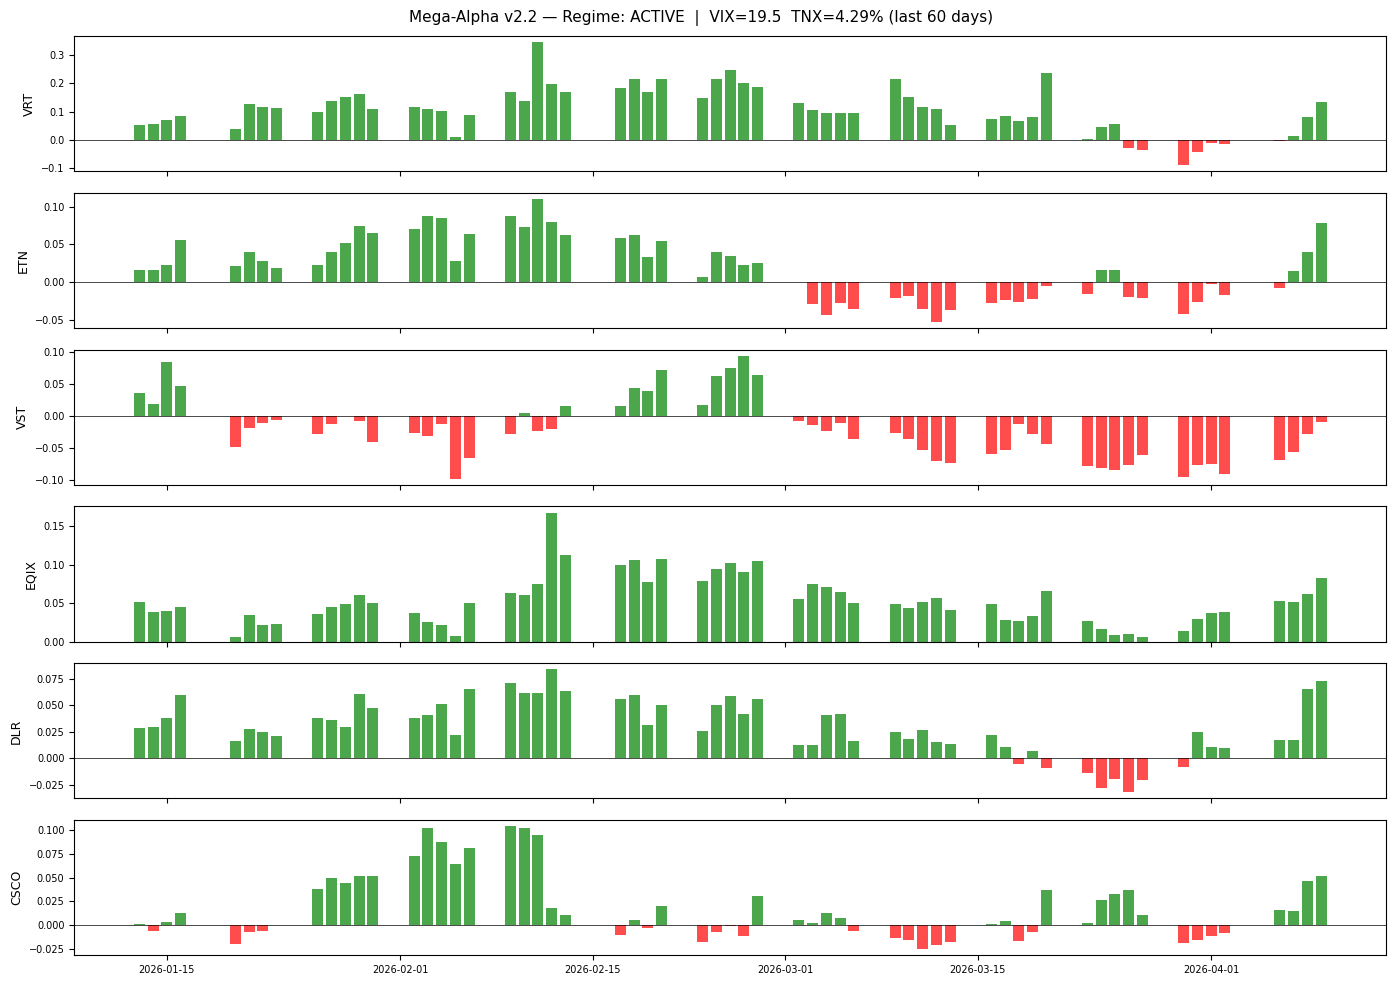

Saved: mega_alpha_v2.2.png
Regime: ACTIVE


In [62]:
# ── Mega-Alpha: Combined Signal Score (v2.2) ─────────────────────────────────

mega_alpha = {}

for t in UNIVERSE:
    w_t = (weights_current[
               (weights_current['Ticker'] == t) &
               (~weights_current['culled'])
           ]
           .set_index('Signal')['w_norm'])

    score = pd.Series(0.0, index=close.index)
    for sig_name, w in w_t.items():
        sig_vals = signals[sig_name][t].reindex(close.index).copy()

        # Apply live sign override from config map
        # Uses current_regime to select the right override direction
        override_sign = TICKER_SIGNAL_OVERRIDES.get(
            (sig_name, t, current_regime), +1
        )
        sig_vals = override_sign * sig_vals

        score = score + w * sig_vals

    mega_alpha[t] = score

mega_alpha_df = pd.DataFrame(mega_alpha)

# Plot last 60 days
fig, axes = plt.subplots(len(UNIVERSE), 1, figsize=(14, 10), sharex=True)
for i, t in enumerate(UNIVERSE):
    recent = mega_alpha_df[t].dropna().iloc[-60:]
    colors = ['green' if v >= 0 else 'red' for v in recent.values]
    axes[i].bar(recent.index, recent.values,
                color=colors, alpha=0.7, width=0.8)
    axes[i].axhline(0, color='black', lw=0.5)
    axes[i].set_ylabel(t, fontsize=9)
    axes[i].tick_params(labelsize=7)

regime_label = (f'Regime: {current_regime.upper()}  |  '
                f'VIX={latest_vix:.1f}  TNX={latest_tnx:.2f}%')
fig.suptitle(
    f'Mega-Alpha v2.2 — {regime_label} (last 60 days)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(f'{FOLDER}/mega_alpha_v2.2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: mega_alpha_v2.2.png')
print(f'Regime: {current_regime.upper()}')


## 5. Regime-Conditional IC

Splits the sample by VIX level and TNX level.
Tests whether signal IC differs meaningfully across regimes —
the key question from the macro signal discussion.

In [63]:
# Define regime masks
vix_low  = close['VIX'] < VIX_THRESHOLD     # risk-on
vix_high = close['VIX'] >= VIX_THRESHOLD    # risk-off
tnx_low  = close['TNX'] < TNX_THRESHOLD     # low rates
tnx_high = close['TNX'] >= TNX_THRESHOLD    # high rates

regimes = {
    'VIX_Low (risk-on)' : vix_low,
    'VIX_High (risk-off)': vix_high,
    'TNX_Low (<4.5%)'   : tnx_low,
    'TNX_High (≥4.5%)'  : tnx_high,
}

# Focus on kept signals from v1
KEPT_SIGNALS = ['SMA200_Distance','Momentum_21d','EMA_Cross_9_21',
                'Bollinger_Pct_B','Momentum_10d','Volume_Surge']

regime_rows = []
for regime_name, mask in regimes.items():
    for sig_name in KEPT_SIGNALS:
        sig_df = signals[sig_name]
        for t in PHOTONICS:
            fwd = close[t].pct_change(21).shift(-21)   # 21d forward return
            sig_vals = sig_df[t]
            df = pd.concat([sig_vals, fwd], axis=1).dropna()
            df.columns = ['signal','fwd']
            df_regime = df[mask.reindex(df.index).fillna(False)]
            if len(df_regime) < 20:
                continue
            ic, pval = spearmanr(df_regime['signal'], df_regime['fwd'])
            regime_rows.append({
                'Regime' : regime_name,
                'Signal' : sig_name,
                'Ticker' : t,
                'IC'     : round(ic, 4),
                'p_value': round(pval, 4),
                'N'      : len(df_regime),
                'Sig'    : pval < 0.05,
            })

regime_df = pd.DataFrame(regime_rows)

# Summary: mean IC per regime × signal
regime_summary = (regime_df.groupby(['Regime','Signal'])
                  .agg(Mean_IC=('IC','mean'), Pct_Sig=('Sig','mean'), N=('N','mean'))
                  .round(4))

print('=== Regime-Conditional IC (21d horizon) ===')
print('Shows how each signal performs in different macro environments.')
print()
print(regime_summary.to_string())

=== Regime-Conditional IC (21d horizon) ===
Shows how each signal performs in different macro environments.

                                     Mean_IC  Pct_Sig      N
Regime              Signal                                  
TNX_High (≥4.5%)    Bollinger_Pct_B  -0.0582   0.3333  100.0
                    EMA_Cross_9_21    0.0562   0.6667  100.0
                    Momentum_10d     -0.0732   0.3333  100.0
                    Momentum_21d      0.0455   0.6667  100.0
                    SMA200_Distance   0.0101   0.6667  100.0
                    Volume_Surge      0.0364   0.0000  100.0
TNX_Low (<4.5%)     Bollinger_Pct_B   0.0345   0.3333  930.0
                    EMA_Cross_9_21    0.0165   0.5000  949.0
                    Momentum_10d      0.0374   0.1667  939.0
                    Momentum_21d      0.0116   0.5000  928.0
                    SMA200_Distance  -0.1560   1.0000  750.0
                    Volume_Surge      0.0083   0.5000  940.0
VIX_High (risk-off) Bollinger_Pct_B  

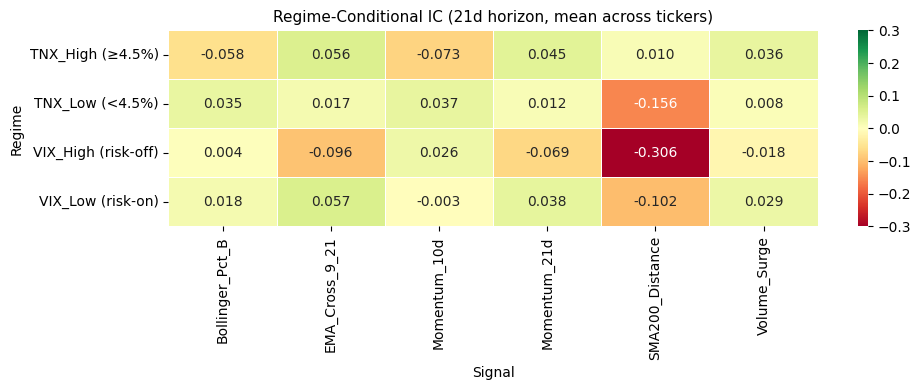

Saved: regime_conditional_ic.png


In [64]:
# Heatmap: IC by regime × signal (averaged across tickers)
pivot_regime = regime_summary['Mean_IC'].unstack(level='Signal')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_regime, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-0.3, vmax=0.3, linewidths=0.5, ax=ax)
ax.set_title('Regime-Conditional IC (21d horizon, mean across tickers)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FOLDER}/regime_conditional_ic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: regime_conditional_ic.png')

## 6. v2 IC: Demeaned Signals vs v1 Baseline

Computes IC using demeaned (X) signals instead of raw signals.
Comparison shows how much drift removal changes the IC estimates.

In [65]:
v2_rows = []
for sig_name in signals:
    sig_df = X[sig_name]   # demeaned
    for t in PHOTONICS:
        for h in HORIZONS:
            ic, pval = compute_ic(sig_df, close, t, h)
            v2_rows.append({'Signal':sig_name,'Ticker':t,'Horizon':h,
                            'IC_v2':ic,'p_v2':pval})

v2_df = pd.DataFrame(v2_rows)

# Best horizon per signal (v2)
v2_summary = (v2_df.groupby(['Signal','Horizon'])
              .agg(Mean_AbsIC_v2=('IC_v2', lambda x: x.abs().mean()))
              .reset_index())

v2_best = (v2_summary.loc[v2_summary.groupby('Signal')['Mean_AbsIC_v2'].idxmax()]
           .rename(columns={'Horizon':'Opt_H_v2'})
           .reset_index(drop=True))

# Merge v1 and v2
compare = best_horizon[['Signal','Optimal_Horizon','Mean_AbsIC']].merge(
    v2_best[['Signal','Opt_H_v2','Mean_AbsIC_v2']], on='Signal')
compare['Delta_IC'] = (compare['Mean_AbsIC_v2'] - compare['Mean_AbsIC']).round(4)
compare = compare.sort_values('Mean_AbsIC_v2', ascending=False)

print('=== v1 vs v2 IC Comparison (demeaning effect) ===')
print(compare.to_string(index=False))

=== v1 vs v2 IC Comparison (demeaning effect) ===
         Signal  Optimal_Horizon  Mean_AbsIC  Opt_H_v2  Mean_AbsIC_v2  Delta_IC
SMA200_Distance               21    0.155238        21       0.155238       0.0
 EMA_Cross_9_21               21    0.065024        21       0.065024       0.0
   Momentum_21d               21    0.064059        21       0.064059       0.0
    Momentum_5d                3    0.063338         3       0.063338       0.0
     VIX_Regime               21    0.062221        21       0.062221       0.0
   Volume_Surge               21    0.049569        21       0.049569       0.0
Bollinger_Pct_B               21    0.045148        21       0.045148       0.0
     TNX_Change                5    0.040237         5       0.040237       0.0
     Oil_Change                5    0.039945         5       0.039945       0.0
   SPX_Relative                5    0.039694         5       0.039694       0.0
   Momentum_10d               21    0.035357        21       0.035357 

## 7. Export All Outputs to Drive

In [66]:
import shutil

# CSVs
ic_df.to_csv(f'{FOLDER}/ic_full_results.csv', index=False)
best_horizon.to_csv(f'{FOLDER}/ic_signal_summary.csv', index=False)
compare.to_csv(f'{FOLDER}/ic_v1_vs_v2.csv', index=False)
regime_df.to_csv(f'{FOLDER}/regime_conditional_ic.csv', index=False)
weight_df.to_csv(f'{FOLDER}/signal_weights.csv', index=False)
mega_alpha_df.to_csv(f'{FOLDER}/mega_alpha_scores.csv')
pd.DataFrame({
    'study'          : STUDY_NAME,
    'universe'       : [UNIVERSE],
    'keep_signals'   : [KEEP_SIGNALS],
    'overrides'      : [str(TICKER_SIGNAL_OVERRIDES)],
    'vix_threshold'  : VIX_THRESHOLD,
    'tnx_threshold'  : TNX_THRESHOLD,
    'start'          : START,
    'run_date'       : pd.Timestamp.today().date(),
    'current_regime' : current_regime,
    'latest_vix'     : latest_vix,
    'latest_tnx'     : latest_tnx,
}, index=[0]).to_csv(f'{FOLDER}/run_manifest.csv', index=False)

# Short interest snapshot
si_df.to_csv(f'{FOLDER}/short_interest_snapshot.csv')

# Credit signal values (last 60 days)
for sig_name in ['CreditSpread', 'CreditSpread_Change', 'YieldCurve_Slope']:
    if sig_name in signals:
        signals[sig_name].iloc[-60:].to_csv(
            f'{FOLDER}/{sig_name}_recent.csv')

# Correlation matrix
sig_corr_data = {sig: signals[sig][PHOTONICS].stack().reset_index(drop=True) for sig in signals}
corr_matrix = pd.DataFrame(sig_corr_data).dropna().corr(method='spearman')
corr_matrix.to_csv(f'{FOLDER}/signal_correlation_matrix.csv')

# Figures already saved inline above

weights_active.to_csv(f'{FOLDER}/signal_weights_active.csv', index=False)
weights_risk_off.to_csv(f'{FOLDER}/signal_weights_risk_off.csv', index=False)

print('All outputs exported to Drive:')
for f in sorted(os.listdir(FOLDER)):
    print(f'  {f}')

All outputs exported to Drive:
  ic_full_results.csv
  ic_signal_summary.csv
  ic_v1_vs_v2.csv
  mega_alpha_scores.csv
  mega_alpha_v2.2.png
  regime_conditional_ic.csv
  regime_conditional_ic.png
  run_manifest.csv
  signal_correlation_matrix.csv
  signal_weights.csv
  signal_weights_active.csv
  signal_weights_risk_off.csv
  step2_demean.png
  universe_correlation.png
  universe_correlation_flags.csv
  universe_correlation_recent.csv
